In [68]:
import baltic as bt
import pandas as pd
import json
import os
import matplotlib as mpl
from matplotlib import pyplot as plt
import requests
from io import StringIO as sio
from matplotlib.patches import Patch
import matplotlib.ticker as ticker
import itertools
import re
import sys
import pprint
import statistics

#use treesort_prepper to prep files and run treesort

#run before_plotting on treesort trees so then it is ready for plotting with baltic


In [69]:
def load_tree(filename):
    mytree, meta = bt.loadJSON(filename)
    return(mytree)

In [70]:

pa_colors = {
    "non_PA":"#CC338B",
    "Pennsylvania":"#5BA8FF"
}
border_colors = {
    "non-border":"#DAA520", #goldenrod
    "PA":"#CC338B", #magenta
    "border": "#6495ED" #cornflower blue
}

div_colors = {"Pennsylvania":"#5BA8FF",
          "Newyork":"#CC338B",
          "Newjersey":"#EEA160",
          "Delaware":"#5CA7A4",
          "Maryland":"#2664A5",
         "Ohio":"#f46d43",#"#544370", 
         "Maine":"#B2313D",
         "Virginia":"#C9AD99",
         "Illinois":"#74add1",
             "California": '#228B22',
             "Colorado": '#804000',
             'Southdakota': "#9794CC"}
domstat_colors = {"domestic":"#5BA8FF",
          "lbm":"#CC338B",
          "wild":"#EEA160",
          "unknown":"#5CA7A4"}


In [71]:
# filename = '../phylo/2026-06-11_largeNorthAm_withPA_wild25_rmdupes_rerun/auspice/json_parse/h5nx_ha.json'
filename = '../phylo/2026-03-19_fullgenome_PAd11_withwild/auspice/h5nx_fullgenome.json'

# filename = '../phylo/2026-04-03_largeNorthAm_withPA_wild25/auspice/json_parse/h5nx_ha.json'

# filename = '../phylo/ha_for_parse/2026-02-24/northam_ha.json'

mytree = load_tree(filename)


Tree height: 1.092000
Tree length: 80.598000
annotations present

Numbers of objects in tree: 1157 (496 nodes and 661 leaves)



In [ ]:
# for k in mytree.Objects:
#     # if k.name == "NODE_0004247":
#     #     print(k.traits)
        
#     # Use get() at each level to avoid KeyErrors if any key is missing
#     value = k.traits.get("node_attrs", {}).get("PA_status", {}).get("value")
#     #value = k.traits.get("node_attrs", {}).get("bird_order", {}).get("value")
    
#     # Check if value is every "unknown"
#     if not value:
#         print(k.name)

In [20]:
k.traits

{'name': 'A/macaque/Montana/59LML/2024',
 'node_attrs': {'div': 0.0172,
  'num_date': {'value': 2024.785,
   'confidence': [2024.75, 2024.832],
   'inferred': True,
   'raw_value': '2024-10-XX'},
  'host': {'value': 'Nonhuman Mammal'},
  'originating_lab': {'value': 'National Institute Of Allergy And Infectious Diseases Niaid/nih'},
  'flyway': {'value': 'Central Flyway',
   'confidence': {'Central Flyway': 1.0},
   'entropy': -1e-12},
  'region': {'value': 'North America'},
  'border_state': {'value': 'non-border',
   'confidence': {'non-border': 1.0},
   'entropy': -1e-12},
  'subtype': {'value': 'h5n1'},
  'country': {'value': 'Usa'},
  'pa_status': {'value': 'non_PA',
   'confidence': {'non_PA': 1.0},
   'entropy': -1e-12},
  'h5_label_clade': {'value': '2.3.4.4b'},
  'geo_region_na': {'value': 'West'},
  'division': {'value': 'Montana'}},
 'branch_attrs': {'mutations': {}},
 'divergence': 0.0172,
 'num_date': 2024.785,
 'num_date_confidence': [2024.75, 2024.832],
 'host': 'Nonhuma

In [40]:
# print(div_colors.keys())
print(border_colors.keys())
#print(host_order.keys())

dict_keys(['non_border', 'PA', 'border'])


In [76]:
def plot_host(mytree):
    plt.rcParams["font.family"] = "Arial"

    fig, ax = plt.subplots(figsize=(20, 20))

    x_attr = lambda k: k.absoluteTime

    # default color #74009F                                 
    def color_by(k):
        # div = k.traits.get("node_attrs", {}).get("border_state", {}).get("value")
        div = k.traits.get("node_attrs", {}).get("wild_dom_lbm", {}).get("value")

        # return border_colors.get(div, "#5CA7A4")
        return domstat_colors.get(div, "#5CA7A4")


    mytree.plotTree(ax, x_attr=x_attr, colour=color_by, width=3)

##make the PA tips go on top!
    # def node_zorder(k):
    #     border = k.traits.get("node_attrs", {}).get("wild_dom_lbm", {}).get("value")
    #     if border == "LBM":
    #         return 6
    #     elif border is not None:  # any other border state
    #         return 5
    #     else:  # non-border
    #         return 2
    
    mytree.plotPoints(
        ax,
        x_attr=x_attr,
        size=100,
        colour=color_by,
        outline_colour='#3f3f3f',
        zorder=3,
        # zorder=node_zorder(k),
        marker='o'
    )
    
# Legend for PA_status ----
    legend_handles = [
        Patch(color=color, label=status if status is not None else "Unknown")
        for status, color in domstat_colors.items()
    ]
    # # Add the "default" color in case a node has no PA_status
    # legend_handles.append(Patch(color="#D1E2F0", label="Not annotated"))

    # legend = ax.legend(
    #     handles=legend_handles,
    #     # title="$\\bf{domesticstatus}$",
    #     title="$\\bf{border state}$",
    #     loc="lower left",
    #     fontsize=20
    # )
    legend = ax.legend(
        handles=legend_handles,
        # title="border state",
        title="domestic status",

        title_fontproperties={'weight': 'bold'},
        loc="lower left",
        fontsize=26
    )
    plt.setp(legend.get_title(), fontsize=30)

    # ---- Clean axis ----
    # ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.set_yticks([])
    ax.set_yticklabels([])
    [ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]
    ax.tick_params(axis='x', labelsize=30, size=15, width=2, color='grey')

    fig.tight_layout()
    plt.savefig("../output_plots//2026-06-16-d11-timetree-domstatDTA.pdf")
    # plt.savefig("../output_plots/2026-6-16-fulltree-timetree-ha-borderstatus.pdf")


    plt.show()


In [115]:
def get_division(k):
    return k.traits.get("node_attrs", {}).get("division", {}).get("value")

print({get_division(k) for k in mytree.Objects})

{'Northcarolina', 'Montana', 'Nevada', 'Delaware', 'Missouri', 'Westvirginia', 'Indiana', 'Iowa', 'Oregon', 'Kansas', 'Georgia', 'Nebraska', 'Washington', 'Durango', 'Minnesota', 'Utah', 'California', 'Maine', 'Pennsylvania', 'Vermont', 'Florida', 'Maryland', 'Tennessee', 'Newjersey', 'Connecticut', 'Michigan', 'Colorado', 'Newyork', 'Virginia', 'Northdakota', 'Newmexico', 'Idaho', 'Southcarolina', 'Wyoming', 'Louisiana', 'Oklahoma', 'Kentucky', 'Southdakota', 'Illinois', 'Newhampshire', 'Sonora', 'Massachusetts', 'Ohio', 'Arizona', 'Arkansas', 'Mississippi'}


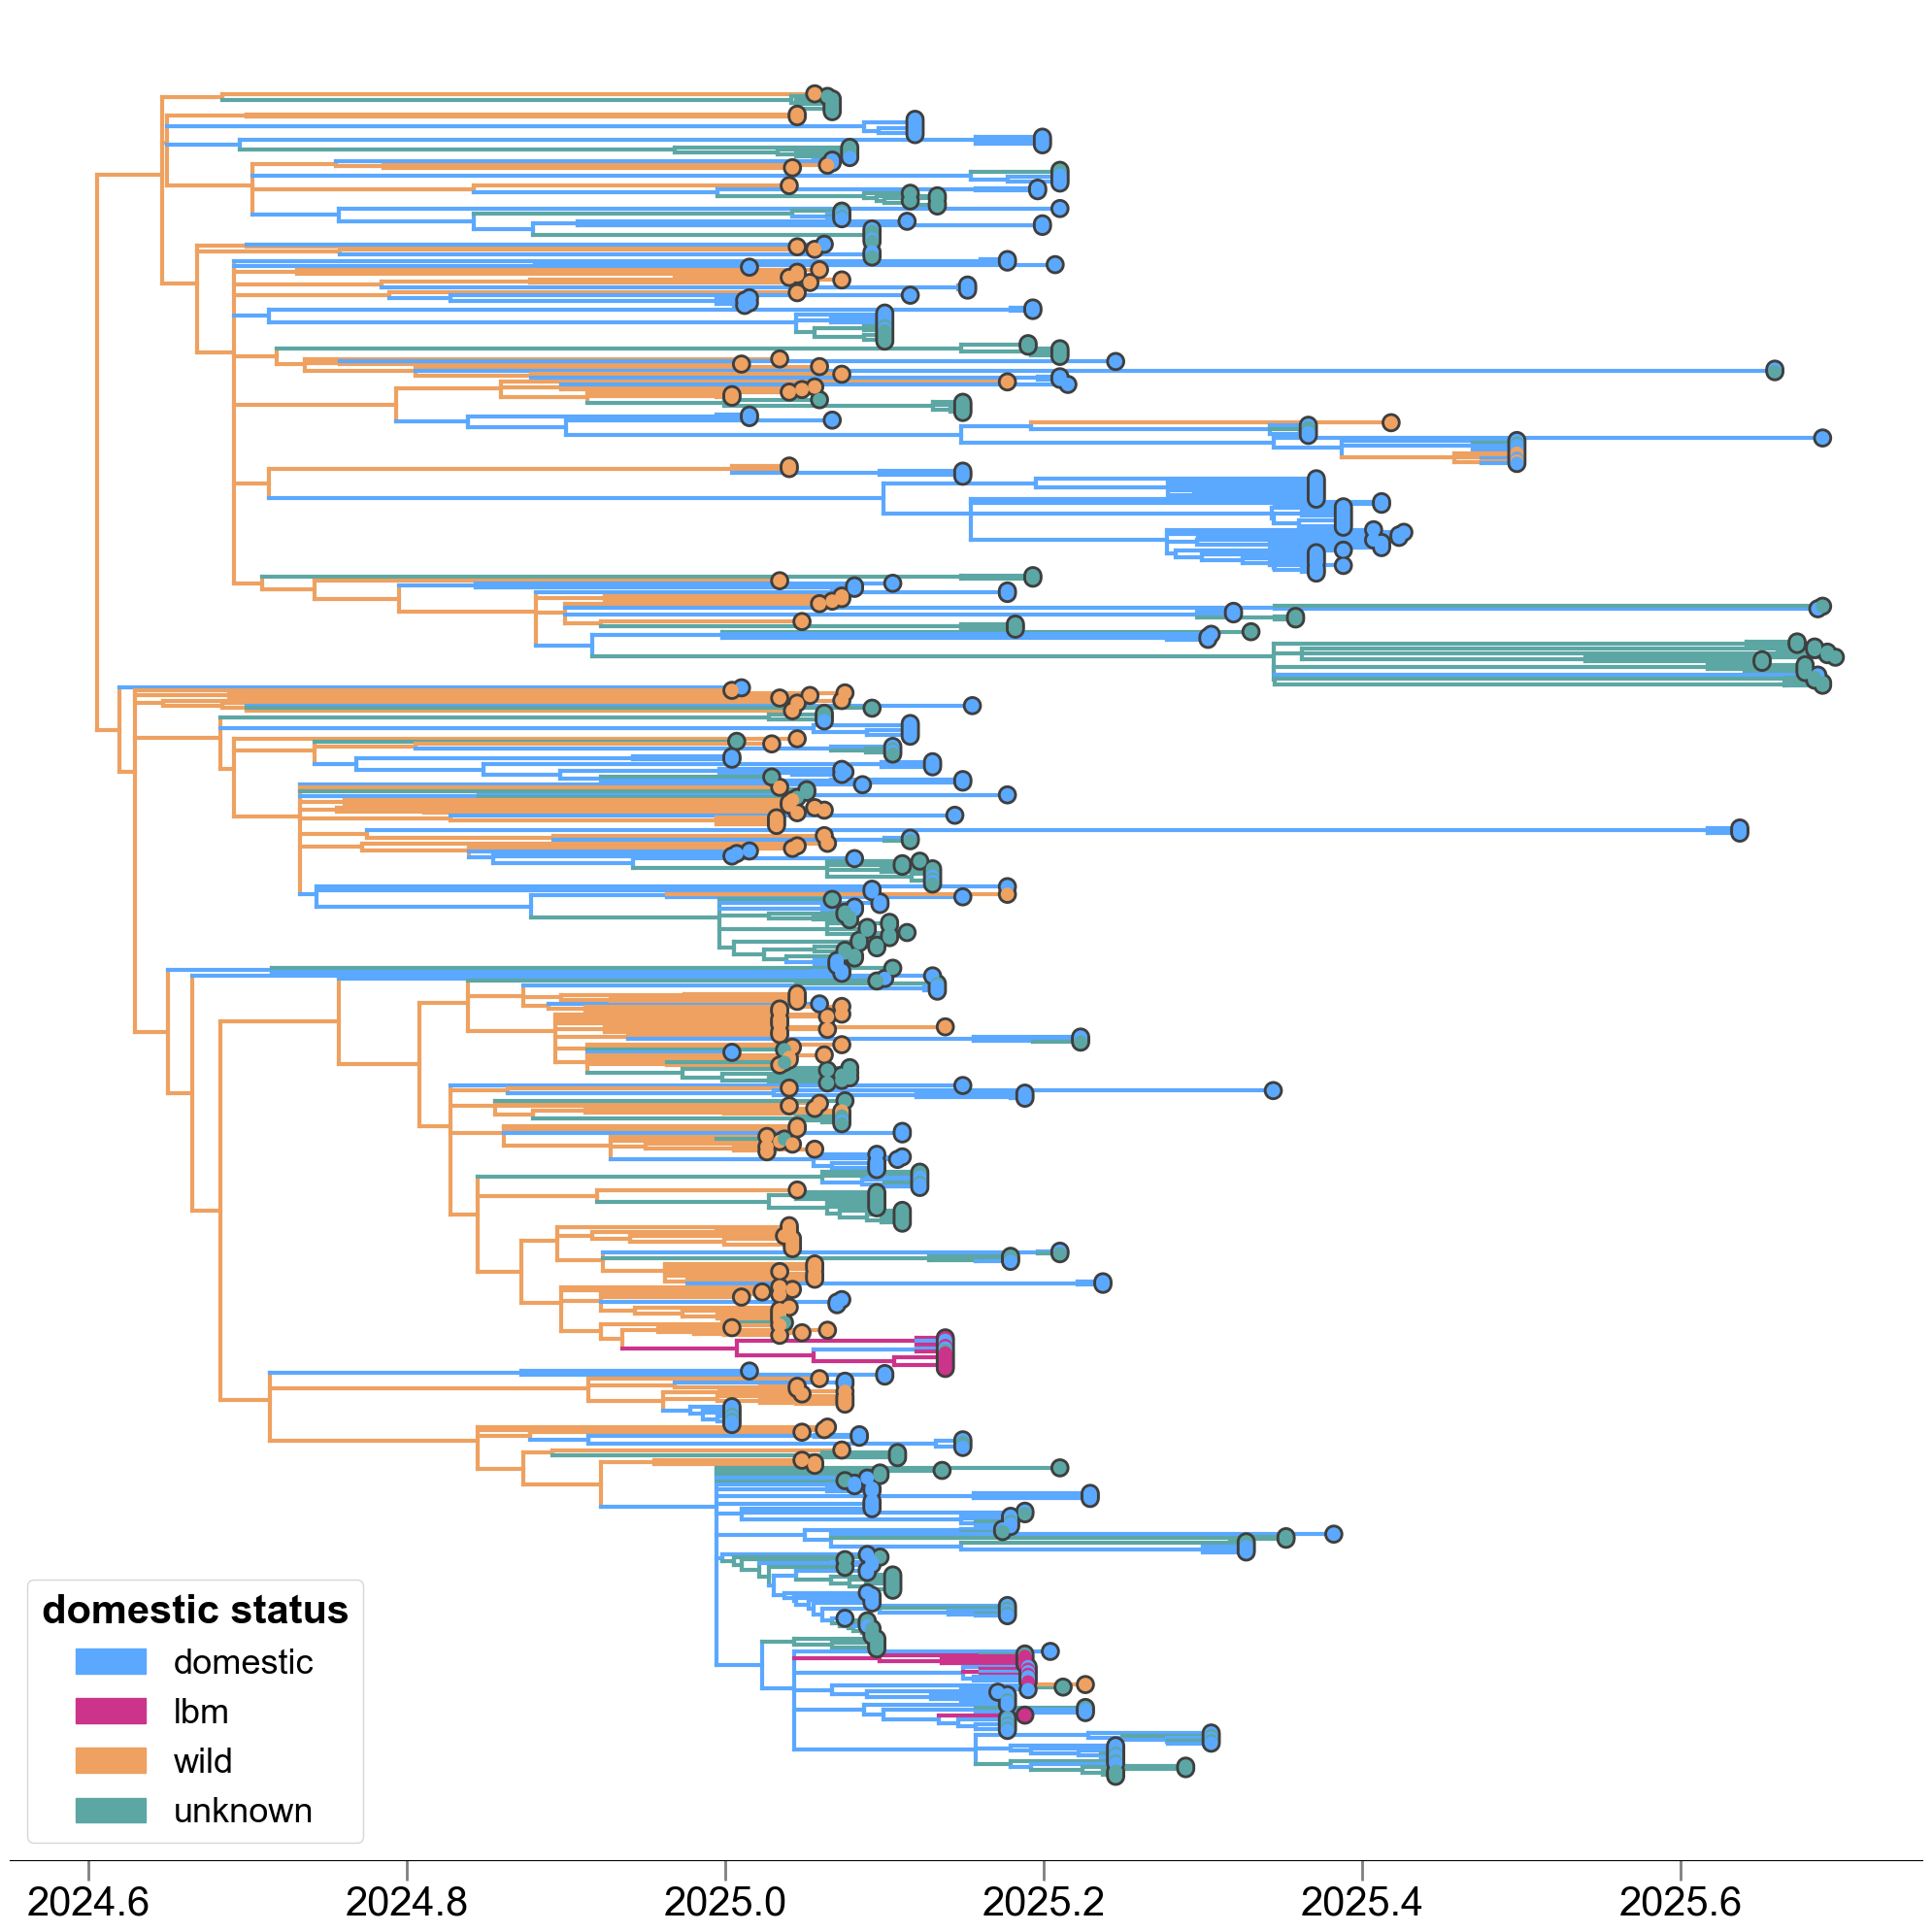

In [77]:
plot_host(mytree)

In [135]:
tree=bt.loadNewick('/Users/asjaeger/Downloads/d11_lbm_march_ny.nwk',absoluteTime=False,verbose=True) ## treeFile here can alternatively be a path to a local file
# tree=bt.loadNewick('/Users/asjaeger/Downloads/b33_fullgenome.nwk',absoluteTime=False,verbose=True) ## treeFile here can alternatively be a path to a local file

tree

0 adding node
1 adding leaf (non-BEAST) A/chicken/Pennsylvania/c_com2/2025
adding branch length (35) 0.000230
59 adding node
60 adding node
61 adding leaf (non-BEAST) a/duck/pa/25008453002original/2025
adding branch length (95) 0.000080
119 adding leaf (non-BEAST) A/duck/Pennsylvania/d_lbm3/2025
adding branch length (150) 0.000000
adding branch length (153) 0.000070
177 adding node
178 adding leaf (non-BEAST) A/chicken/Pennsylvania/c_lbm8/2025
adding branch length (212) 0.000380
236 adding node
237 adding leaf (non-BEAST) A/chicken/Pennsylvania/c_lbm6/2025
adding branch length (271) 0.000000
274 adding leaf (non-BEAST) A/chicken/Pennsylvania/c_lbm7/2025
adding branch length (308) 0.000000
adding branch length (311) 0.000070
adding branch length (335) 0.000150
adding branch length (359) 0.000230
383 adding node
384 adding leaf (non-BEAST) a/chicken/pa/25008666003original/2025
adding branch length (421) 0.000150
445 adding node
446 adding leaf (non-BEAST) A/chicken/Pennsylvania/c_lbm9/20

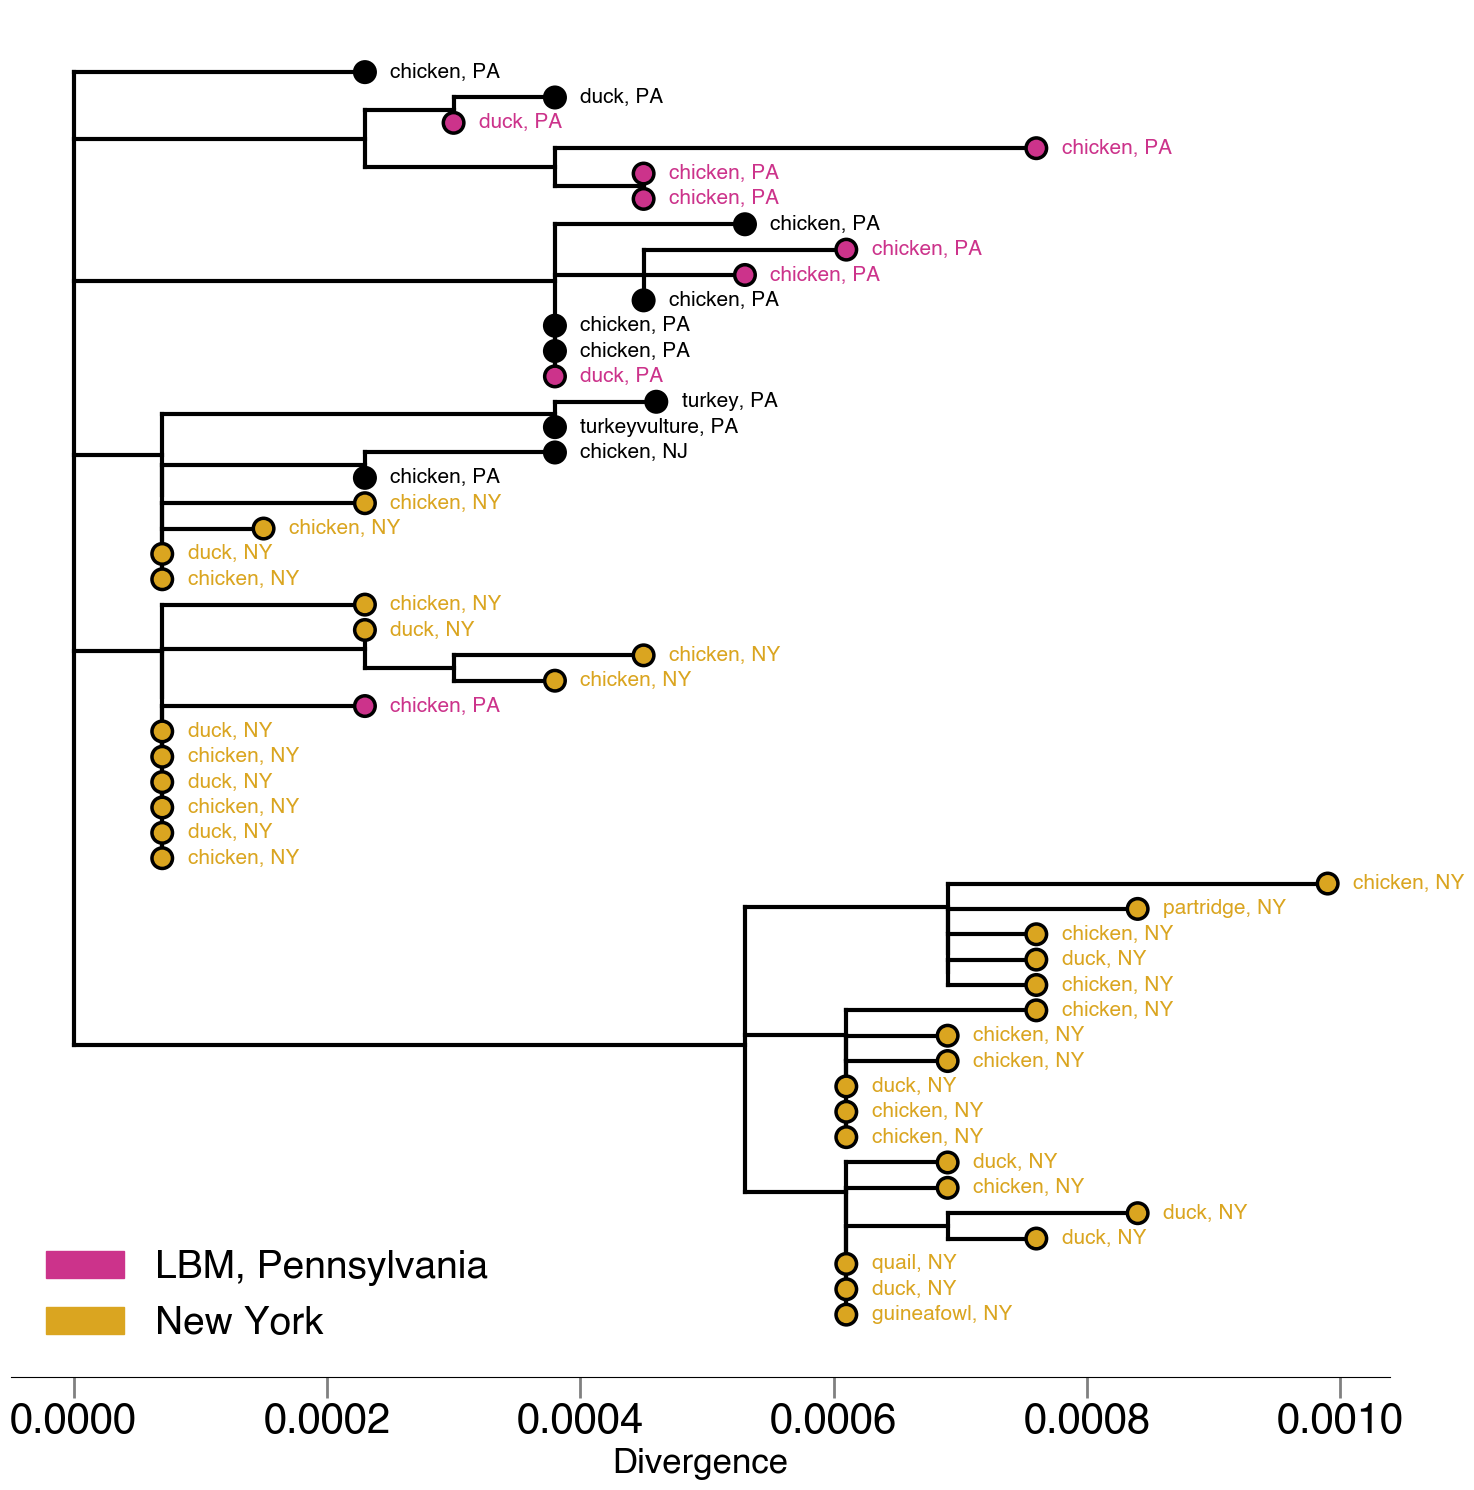

In [158]:
##plotting zoomed in LBM clades divergence view

def plot_div_tree(tree):
    
    import matplotlib.pyplot as plt
    plt.rcParams["font.family"] = "Helvetica"

    # Ensure y positions exist
    tree.traverse_tree()
    tree.sortBranches()

    fig, ax = plt.subplots(figsize=(15, 15))

    x_attr = lambda k: k.x
    y_attr = lambda k: k.y

    # # --- Color function ---
    # def tip_color(node):
    #     name = node.name.lower()
    #     if "khaki" in name:
    #         return "cornflowerblue"
    #     if "chicken" in name:
    #         return "goldenrod"
    #     return "black"
    # # ----------------------
    # --- Color function ---
    def tip_color(node):
        name = node.name.lower()
        
        if any(k in name for k in ["lbm"]):
            return "#CC338B"
        if any(k in name for k in ["ny", "newyork"]):
            return "goldenrod"
        
        return "black"
    # ----------------------

    # --- Short name function ---
    # def short_name(node_name):
    #     # Extract 4th field (kc_com8) from A/khakicampbell/Pennsylvania/kc_com8/2023
    #     parts = node_name.split("/")
    #     if len(parts) >= 4:
    #         return parts[3]
    #     return node_name
    # def short_name(node_name):
    #     # Extract 4th field (kc_com8) from A/khakicampbell/Pennsylvania/kc_com8/2023
    #     parts = node_name.split("/")
    #     if len(parts) >= 4:
    #         return ", ".join(parts[1:3])  
    #     return node_name
    # ----------------------

    def short_name(node_name):
        parts = node_name.split("/")
        
        if len(parts) >= 4:
            # grab species + location (or however many fields you want)
            selected = parts[1:3]
    
            # normalize / rename terms
            rename_map = {
                "pa": "PA",
                "pennsylvania": "PA",
                "newyork": "NY",
                "ny": "NY",
                "nj":"NJ"
            }
    
            cleaned = []
            for item in selected:
                key = item.lower()
                cleaned.append(rename_map.get(key, item))  # replace if in map
    
            return ", ".join(cleaned)

        return node_name
    # Plot branches
    tree.plotTree(
        ax,
        x_attr=x_attr,
        y_attr=y_attr,
        width=3
    )

    # Plot points with color by species
    tree.plotPoints(
        ax,
        x_attr=x_attr,
        y_attr=y_attr,
        size=150,
        marker='o',
        zorder=3,
        colour=tip_color
    )

    # --- Add tip labels ---
    for node in tree.Objects:
        if node.branchType == "leaf":
            ax.text(
                x_attr(node) + 0.00002,
                y_attr(node),
                short_name(node.name),
                fontsize=15,
                va='center',
                color=tip_color(node)   # label color matches tip color
            )
    # -----------------------

    # --- Legend ---
    legend_elements = [
        Patch(facecolor="#CC338B", edgecolor="#CC338B", label="LBM, Pennsylvania"),
        Patch(facecolor="goldenrod", edgecolor="goldenrod", label="New York")
    ]
    ax.legend(handles=legend_elements, loc='lower left', fontsize=28, frameon=False)
    # --------------

    # Cleaned-up axis styling
    ax.set_yticks([])
    ax.set_yticklabels([])
    [ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]
    ax.tick_params(axis='x', labelsize=30, size=15, width=2, color='grey')
    ax.set_xlabel("Divergence", fontsize=25)

    fig.tight_layout()
    # plt.savefig('../phylo_scripts_analysis/output_figs/2025-11-14-pa-comm-concat-div-tree.pdf', format='pdf')
    plt.savefig('../phylo_scripts_analysis/output_figs/2026-04-16-d11_lbm_march_ny.png', format='png')

    plt.show()
plot_div_tree(tree)

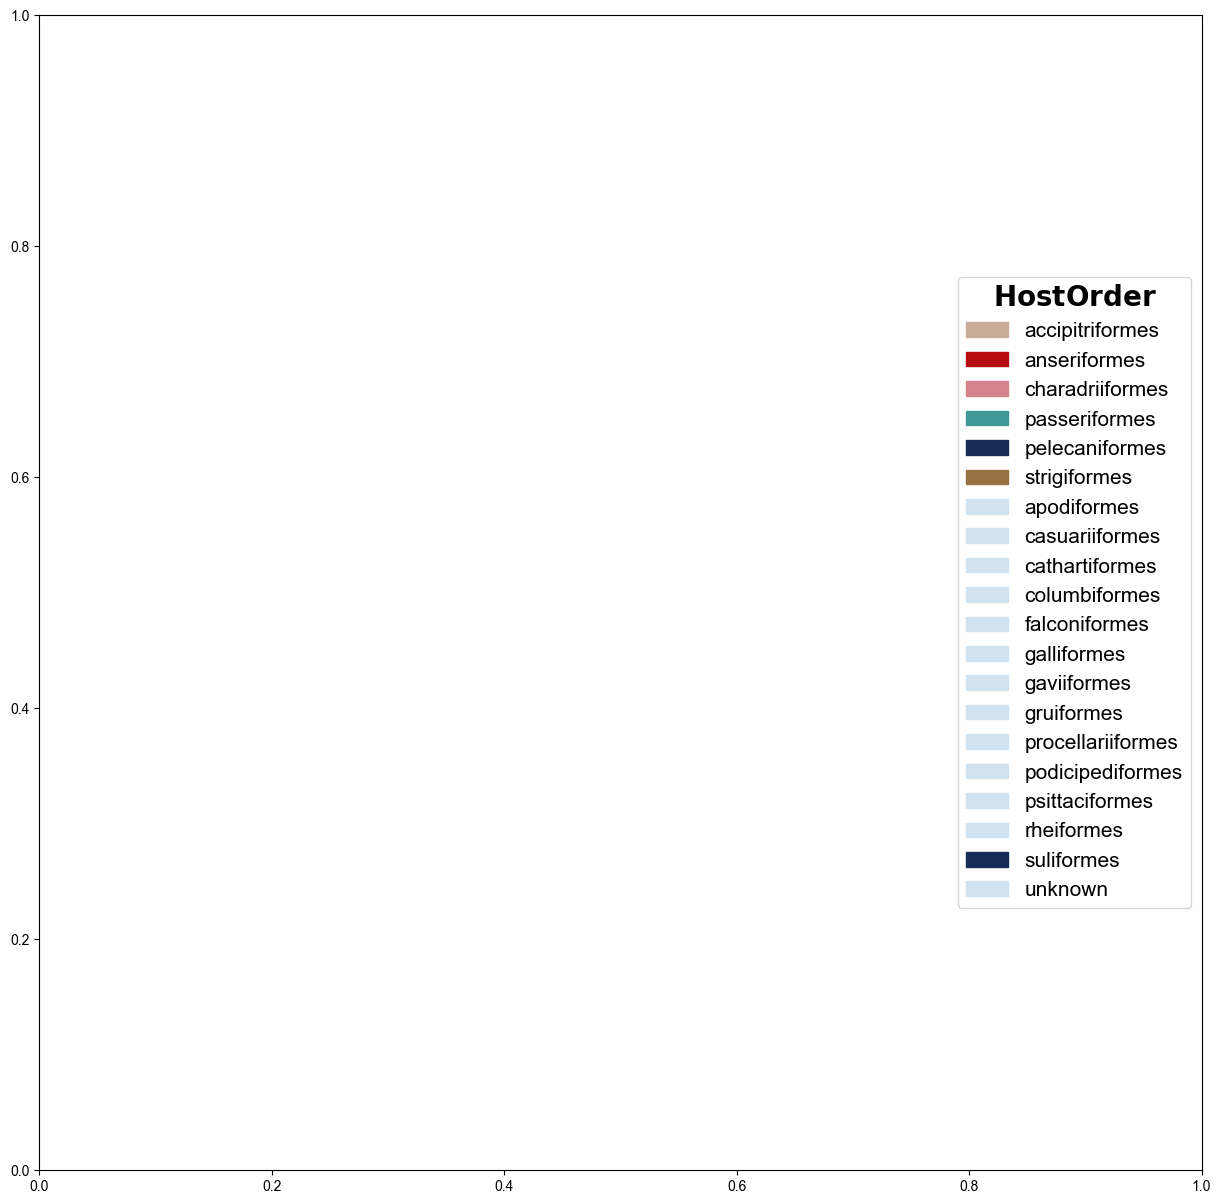

<Figure size 640x480 with 0 Axes>

In [63]:
fig, ax = plt.subplots(figsize=(15, 15))

legend_handles = [Patch(color=color, label=bird_order) for bird_order, color in host_order.items()]

legend = ax.legend(handles=legend_handles, title="$\\bf{Host Order}$", loc="center right", fontsize='15')
plt.setp(legend.get_title(),fontsize=20)

plt.show()
plt.savefig("./Nextstrain/2025-02-24_NAm_aves-wild_division_nopacific_countypriority/hostcolor_legend.pdf")